# Spectrum Denoising Dataset Preview

This notebook demonstrates the `DenoisingDataGenerator` which creates paired noisy-clean datasets for signal reconstruction models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.denoising.generator import DenoisingDataGenerator
from src.data.common.base_generator import GeneratorConfig, preview_dataset

## Generate Paired Samples
Generating 10 samples. Each sample consists of a noisy input spectrum and a clean ground truth spectrum.

In [2]:
gen = DenoisingDataGenerator(seed=777)
config = GeneratorConfig.Presets.fast_scan()
config.summary()

X_noisy, X_clean = gen.generate_dataset(num_samples=10, config=config)

print(f"Noisy spectra shape: {X_noisy.shape}")
print(f"Clean spectra shape: {X_clean.shape}")

----------------------------------------
      XRF Generator Configuration       
----------------------------------------
s_counts_range      : (10000, 30000)
n_counts_range      : (10000, 30000)
b_counts_range      : (3000, 8000)
c_counts_range      : (3000, 3000)
escape_prob         : 1.0
sum_peaks_prob      : 1.0
decal_prob          : 0.2
kvp_range           : (30.0, 30.0)
angle_range         : (46.0, 46.0)
mas_range           : (9.0, 9.0)
target_materials    : ['Mo']
filters             : [('Be', 0.127), ('Air', 10.0)]
----------------------------------------


Generating Denoising Dataset: 100%|██████████| 10/10 [00:12<00:00,  1.29s/it]

Noisy spectra shape: (10, 600)
Clean spectra shape: (10, 600)


## Visualization
Overlaying the noisy input and clean target to visualize the denoising task.

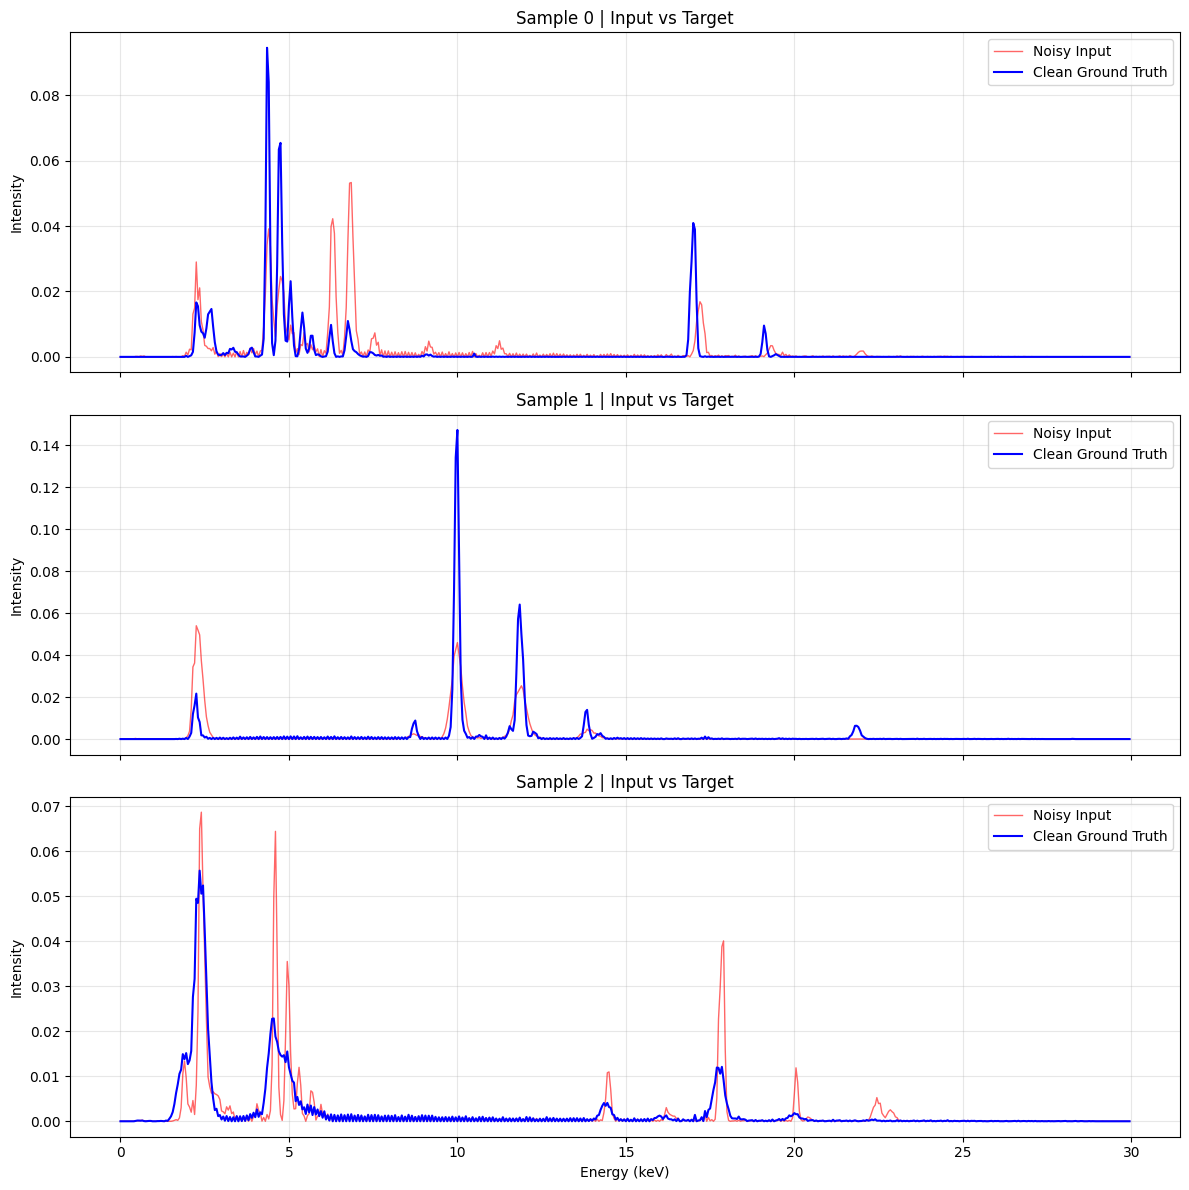

In [3]:
num_previews = 3
energies = np.arange(0, 30, 0.05)

fig, axes = plt.subplots(num_previews, 1, figsize=(12, 4 * num_previews), sharex=True)

for i in range(num_previews):
    ax = axes[i]
    ax.plot(energies, X_noisy[i], label="Noisy Input", alpha=0.6, color='red', lw=1)
    ax.plot(energies, X_clean[i], label="Clean Ground Truth", color='blue', lw=1.5)
    
    ax.set_title(f"Sample {i} | Input vs Target")
    ax.set_ylabel("Intensity")
    ax.legend()
    ax.grid(alpha=0.3)

plt.xlabel("Energy (keV)")
plt.tight_layout()
plt.show()

## Residual Analysis
Looking at the noise residual (Noisy - Clean).

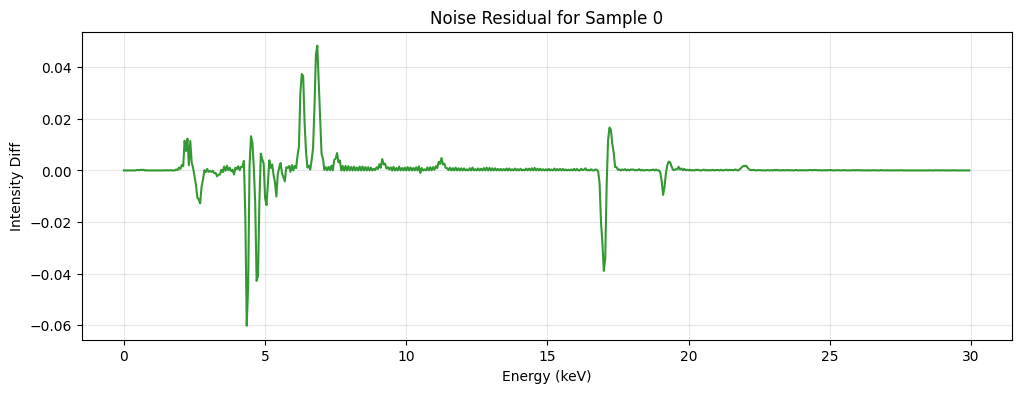

In [4]:
residual = X_noisy[0] - X_clean[0]

plt.figure(figsize=(12, 4))
plt.plot(energies, residual, color='green', alpha=0.8)
plt.title("Noise Residual for Sample 0")
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity Diff")
plt.grid(alpha=0.3)
plt.show()